In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("studentPerformance.csv")
df.head()
df.shape

(500, 5)

In [19]:
df.columns

Index(['Study_Hours', 'Attendance', 'Practice_Tests', 'Final_Score',
       'Pass_Fail'],
      dtype='object')

In [20]:
X = df [['Study_Hours', 'Attendance', 'Practice_Tests']].values
y = df ['Final_Score'].values
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 3)
y shape: (500,)


In [21]:
Xmean = np.mean(X,axis=0)
Xstd = np.std(X,axis=0)
X_scaled = (X-Xmean)/Xstd

In [22]:
def predict(x,w,b):
  return (np.dot(x,w)+b)


In [23]:
def compute_cost(x,w,y,b):
  m=x.shape[0]
  cost=0
  ypred=predict(x,w,b)
  for i in range (m):
    err = (ypred[i]-y[i])**2
    cost += err
  return (cost/(2*m))


In [24]:
def compute_gradient(x,w,y,b):
  m,n=x.shape
  djw=np.zeros(n)
  djb=0
  ypred=predict(x,w,b)
  for j in range (n):
    for i in range (m):
      err=ypred[i]-y[i]
      djw[j]=djw[j] + err*x[i,j]
  for i in range (m):
    djb=djb + ypred[i]-y[i]
  return (djw/m,djb/m)



In [25]:
def gradient_descent(x,w,y,b,alpha,iterations):
  costHistory=[]
  for i in range (iterations):
    djw,djb=compute_gradient(x,w,y,b)
    if i < 100000:
      w-= alpha*djw
      b-= alpha*djb
      cost=compute_cost(x,w,y,b)
      costHistory.append(cost)
      if i%100 ==0:
        print(f"Iteration {i}, Cost = {cost}")
  return (w,b,costHistory)

In [31]:
alpha = 0.02
iterations = 3000

w = np.zeros(X_scaled.shape[1])
b = 0
X_train=X_scaled[:400]
X_test=X_scaled[400:]
y_train=y[:400]
y_test=y[400:]
w, b, costHistory = gradient_descent(X_train, w, y_train, b, alpha, iterations)

Iteration 0, Cost = 2566.657025344867
Iteration 100, Cost = 60.79796137152564
Iteration 200, Cost = 16.12156742181158
Iteration 300, Cost = 15.313166022594437
Iteration 400, Cost = 15.298269785689378
Iteration 500, Cost = 15.297988866611426
Iteration 600, Cost = 15.297983412042289
Iteration 700, Cost = 15.297983302320766
Iteration 800, Cost = 15.297983300022883
Iteration 900, Cost = 15.297983299972657
Iteration 1000, Cost = 15.297983299971522
Iteration 1100, Cost = 15.297983299971497
Iteration 1200, Cost = 15.297983299971493
Iteration 1300, Cost = 15.297983299971493
Iteration 1400, Cost = 15.297983299971477
Iteration 1500, Cost = 15.297983299971479
Iteration 1600, Cost = 15.297983299971488
Iteration 1700, Cost = 15.297983299971495
Iteration 1800, Cost = 15.297983299971488
Iteration 1900, Cost = 15.297983299971499
Iteration 2000, Cost = 15.297983299971499
Iteration 2100, Cost = 15.297983299971499
Iteration 2200, Cost = 15.297983299971499
Iteration 2300, Cost = 15.297983299971499
Iterati

In [27]:
def mse(y_true,y_pred):
  return np.mean((y_true-y_pred)**2)
def r2_score(y_true,y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


In [32]:
y_pred = np.dot(X_test, w)+ b
print(w,b)
print("MSE:", mse(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

[13.88776566  5.40869977 10.25864729] 70.70254640625481
MSE: 27.83491237706371
R2: 0.9268494046902824


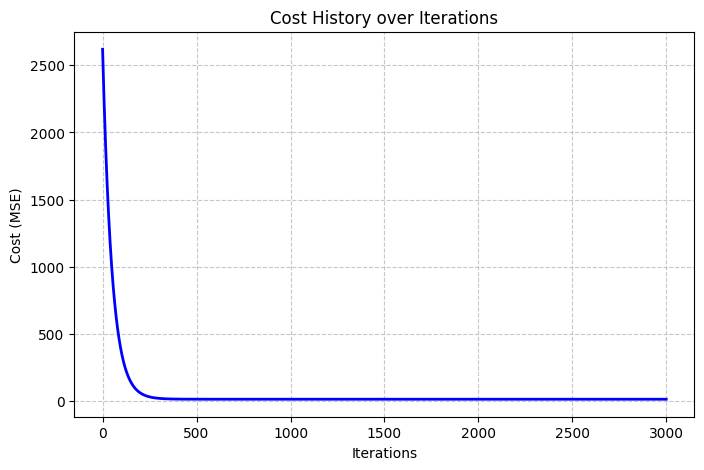

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(costHistory)), costHistory, color='blue', linewidth=2)
plt.title('Cost History over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1108/2194615082.py:3: SyntaxWarning: invalid escape sequence '\h'
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Fit ($y = \hat{y}$)')


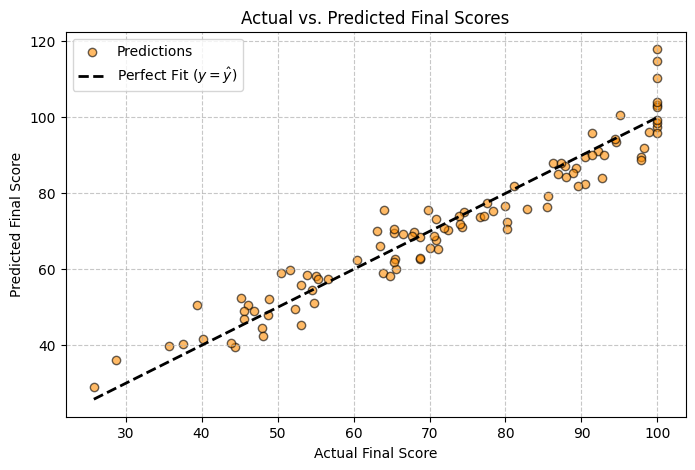

In [33]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='darkorange', alpha=0.6, edgecolors='k', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Fit ($y = \hat{y}$)')
plt.title('Actual vs. Predicted Final Scores')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
for i in range(5):
    indices = np.random.permutation(len(X_scaled))

    X_shuffled = X_scaled[indices]
    y_shuffled = y[indices]

    split = int(0.8 * len(X_scaled))

    X_train = X_shuffled[:split]
    y_train = y_shuffled[:split]

    X_test = X_shuffled[split:]
    y_test = y_shuffled[split:]

    w = np.zeros(X_train.shape[1])
    b = 0

    w, b, cost_history = gradient_descent(X_train,w, y_train, b, alpha=0.01,iterations=3500)

    y_pred = np.dot(X_test, w) + b

    r2 = r2_score(y_test, y_pred)

    print(f"Run {i+1}: R² = {r2}")

Iteration 0, Cost = 2605.829606581401
Iteration 100, Cost = 373.3630548607405
Iteration 200, Cost = 63.57958779351427
Iteration 300, Cost = 20.385805346870804
Iteration 400, Cost = 14.332779755025147
Iteration 500, Cost = 13.480027278803194
Iteration 600, Cost = 13.359220875172802
Iteration 700, Cost = 13.34200653180124
Iteration 800, Cost = 13.339538592634456
Iteration 900, Cost = 13.339182536950494
Iteration 1000, Cost = 13.339130833852868
Iteration 1100, Cost = 13.339123276315968
Iteration 1200, Cost = 13.339122164253803
Iteration 1300, Cost = 13.339121999532205
Iteration 1400, Cost = 13.33912197497385
Iteration 1500, Cost = 13.339121971289162
Iteration 1600, Cost = 13.339121970732947
Iteration 1700, Cost = 13.33912197064852
Iteration 1800, Cost = 13.339121970635599
Iteration 1900, Cost = 13.33912197063364
Iteration 2000, Cost = 13.339121970633334
Iteration 2100, Cost = 13.339121970633277
Iteration 2200, Cost = 13.339121970633274
Iteration 2300, Cost = 13.339121970633267
Iteration 2